In [1]:
#Import necessary libraries

#%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import astropy
from astropy.table import Table, hstack
import scipy.stats
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.coordinates import Galactic
from astropy.coordinates import ICRS
import astropy.coordinates as apycord
import random
from cycler import cycler
import astropy.table

import re
import csv
import sys
import scipy
import pickle
import astropy
import pylab as p
import random as random
import numpy.random as rand
import astropy.io.fits as pyfits


from math import *
from math import cos, sin, pi
from numpy import *
from matplotlib import *
from scipy.interpolate import *
from astropy.table import join
from matplotlib.colors import LogNorm
import statistics as stat

# from scipy.integrate import trapz
# from scipy.integrate import quad

from astropy.table import QTable
from astropy.table import Table
import astropy.units as u
from astropy.coordinates import Angle

import zipfile as zf
import glob
from astropy.io import fits
import tarfile
import gzip
import shutil
import pandas as pd
from scipy.optimize import curve_fit

from concurrent.futures import ThreadPoolExecutor

import emcee
import corner

from PIL import Image
from IPython.display import display
import os

In [2]:
#Read in the data covered by RUBIES (what we have spectra for) and by UNICORN (What we have photometric images for)

unicorn_area = Table.read("NIRSpec_Area_Photometry_EGS_UDS.fits") #len of 131720
rubies_sample = Table.read("RUBIES_PRISM_Auto_spec_z.fits") #len of 1951

In [3]:
#The following redshift masks were deemed unnecessary and revoked

#Redshift mask on the file that contains all objects in the NIRSpec MSA pointings area, regardless of if they had a slit

unicorn_areaz = unicorn_area#[(unicorn_area.columns['ZPEAK']>2) & (unicorn_area.columns['ZPEAK']<7.1)] #len of 60798

#Redshift mask on my data as well, for these are the redshift bins that matter
rubies_samplez = rubies_sample#[(rubies_sample.columns['z_test']>2) & (rubies_sample.columns['z_test']<7.1)] #len of 1108

In [4]:
rubies_samplez2 = rubies_samplez[(rubies_samplez.columns['MSA_ID']>0)]
rubies_samplez = rubies_samplez2 #cut out the negative MSA_ID values!

In [5]:
#Display all RUBIES data
rubies_samplez

MSA_ID,RA,DEC,filename,z_test,resids
int64,float64,float64,bytes60,float64,float64
52296,34.278927,-5.223889499999984,jw04233001002_PRIMER-UDS-FULL-V4_CLEAR_PRISM_s52296_x1d.fits,2.6328542151254606,2458.2603551179045
42038,214.96335773439,52.91003671599,jw04233005002_CEERS-FULL-V2_CLEAR_PRISM_s42038_x1d.fits,2.5601442533401495,2771.7018640633964
36816,34.2955068,-5.251740600000005,jw04233001003_PRIMER-UDS-FULL-V4_CLEAR_PRISM_s36816_x1d.fits,6.168155958940158,2383.5898727655062
6998,215.11058346568,52.94181834399,jw04233005001_CEERS-FULL-V2_CLEAR_PRISM_s06998_x1d.fits,5.313958752218661,2613.5330601057935
40133,214.79945426768,52.78671878462,jw04233005003_CEERS-FULL-V2_CLEAR_PRISM_s40133_x1d.fits,3.4517336422971274,3172.3216637412675
15570,34.2702262,-5.288682800000004,jw04233001001_PRIMER-UDS-FULL-V4_CLEAR_PRISM_s15570_x1d.fits,3.2962389182187524,3432.346791228946
3266,215.04722432443,52.88856071529,jw04233005002_CEERS-FULL-V2_CLEAR_PRISM_s03266_x1d.fits,7.197296485426223,374.59403662816817
23925,34.2348255,-5.273297300000024,jw04233001001_PRIMER-UDS-FULL-V4_CLEAR_PRISM_s23925_x1d.fits,--,--
62484,214.81963023623,52.85449765374,jw04233006002_CEERS-FULL-V2_CLEAR_PRISM_s62484_x1d.fits,2.13128580349622,2257.761111981794


In [6]:
#Display all UNICORN data
unicorn_areaz

ID_1,COORDID,RA,DEC,SELECTCAT,X,Y,KRON_RADIUS,A_IMAGE,B_IMAGE,THETA_IMAGE,APCORR,APCORR_WINGS,STELLARITY,ISOAREA_IMAGE,STARFLAGS,DEPTHTIER,FLUX_F435W,FLUXERR_F435W,RH_F435W,FWHM_F435W,FLUXERR_LOCAL_F435W,EDGEFLAGS_51PIX_F435W,EDGEFLAGS_21PIX_F435W,FLUX_F606W,FLUXERR_F606W,RH_F606W,FWHM_F606W,FLUXERR_LOCAL_F606W,EDGEFLAGS_51PIX_F606W,EDGEFLAGS_21PIX_F606W,FLUX_F814W,FLUXERR_F814W,RH_F814W,FWHM_F814W,FLUXERR_LOCAL_F814W,EDGEFLAGS_51PIX_F814W,EDGEFLAGS_21PIX_F814W,FLUX_F105W,FLUXERR_F105W,RH_F105W,FWHM_F105W,FLUXERR_LOCAL_F105W,EDGEFLAGS_51PIX_F105W,EDGEFLAGS_21PIX_F105W,FLUX_F125W,FLUXERR_F125W,RH_F125W,FWHM_F125W,FLUXERR_LOCAL_F125W,EDGEFLAGS_51PIX_F125W,EDGEFLAGS_21PIX_F125W,FLUX_F140W,FLUXERR_F140W,RH_F140W,FWHM_F140W,FLUXERR_LOCAL_F140W,EDGEFLAGS_51PIX_F140W,EDGEFLAGS_21PIX_F140W,FLUX_F160W,FLUXERR_F160W,RH_F160W,FWHM_F160W,FLUXERR_LOCAL_F160W,EDGEFLAGS_51PIX_F160W,EDGEFLAGS_21PIX_F160W,FLUX_F090W,FLUXERR_F090W,RH_F090W,FWHM_F090W,FLUXERR_LOCAL_F090W,EDGEFLAGS_51PIX_F090W,EDGEFLAGS_21PIX_F090W,FLUX_F115W,FLUXERR_F115W,RH_F115W,FWHM_F115W,FLUXERR_LOCAL_F115W,EDGEFLAGS_51PIX_F115W,EDGEFLAGS_21PIX_F115W,FLUX_F150W,FLUXERR_F150W,RH_F150W,FWHM_F150W,FLUXERR_LOCAL_F150W,EDGEFLAGS_51PIX_F150W,EDGEFLAGS_21PIX_F150W,FLUX_F200W,FLUXERR_F200W,RH_F200W,FWHM_F200W,FLUXERR_LOCAL_F200W,EDGEFLAGS_51PIX_F200W,EDGEFLAGS_21PIX_F200W,FLUX_F277W,FLUXERR_F277W,RH_F277W,FWHM_F277W,FLUXERR_LOCAL_F277W,EDGEFLAGS_51PIX_F277W,EDGEFLAGS_21PIX_F277W,FLUX_F356W,FLUXERR_F356W,RH_F356W,FWHM_F356W,FLUXERR_LOCAL_F356W,EDGEFLAGS_51PIX_F356W,EDGEFLAGS_21PIX_F356W,FLUX_F410M,FLUXERR_F410M,RH_F410M,FWHM_F410M,FLUXERR_LOCAL_F410M,EDGEFLAGS_51PIX_F410M,EDGEFLAGS_21PIX_F410M,FLUX_F444W,FLUXERR_F444W,RH_F444W,FWHM_F444W,FLUXERR_LOCAL_F444W,EDGEFLAGS_51PIX_F444W,EDGEFLAGS_21PIX_F444W,FLUX_F470N,FLUXERR_F470N,RH_F470N,FWHM_F470N,FLUXERR_LOCAL_F470N,EDGEFLAGS_51PIX_F470N,EDGEFLAGS_21PIX_F470N,ID_2,ZA,ZP,ZM1,ZM2,ZPEAK,CHIA,CHI2_LOW,ZLOW,ZL68,ZU68,ZL95,ZU95,INT_PZ0,INT_PZ1,INT_PZ2,INT_PZ3,INT_PZ4,INT_PZ5,INT_PZ6,INT_PZ7,INT_PZ8,INT_PZ9,INT_PZ10,INT_PZ11,INT_PZ12,INT_PZ13,INT_PZ14,INT_PZ15,INT_PZ16,INT_PZ17,INT_PZ18,INT_PZ19,INT_PZ9P5_12,INT_PZ12_15,INT_PZ15_20,INT_ZGT3,INT_ZGT4,INT_ZGT5,INT_ZGT6,INT_ZGT7,INT_ZGT8,INT_ZGT9,INT_ZGT10,INT_ZGT11,INT_ZGT12,INT_ZGT13,INT_ZGT14,INT_ZGT15,SAMPLE,SAMPLE_JWST,ID,FLUXERR_LOCAL_D0P2_F435W,FLUXERR_LOCAL_D0P3_F435W,FLUXERR_LOCAL_D0P4_F435W,FLUXERR_LOCAL_D0P5_F435W,FLUXERR_LOCAL_D0P2_F606W,FLUXERR_LOCAL_D0P3_F606W,FLUXERR_LOCAL_D0P4_F606W,FLUXERR_LOCAL_D0P5_F606W,FLUXERR_LOCAL_D0P2_F814W,FLUXERR_LOCAL_D0P3_F814W,FLUXERR_LOCAL_D0P4_F814W,FLUXERR_LOCAL_D0P5_F814W,FLUXERR_LOCAL_D0P2_F125W,FLUXERR_LOCAL_D0P3_F125W,FLUXERR_LOCAL_D0P4_F125W,FLUXERR_LOCAL_D0P5_F125W,FLUXERR_LOCAL_D0P2_F140W,FLUXERR_LOCAL_D0P3_F140W,FLUXERR_LOCAL_D0P4_F140W,FLUXERR_LOCAL_D0P5_F140W,FLUXERR_LOCAL_D0P2_F160W,FLUXERR_LOCAL_D0P3_F160W,FLUXERR_LOCAL_D0P4_F160W,FLUXERR_LOCAL_D0P5_F160W,FLUXERR_LOCAL_D0P2_F090W,FLUXERR_LOCAL_D0P3_F090W,FLUXERR_LOCAL_D0P4_F090W,FLUXERR_LOCAL_D0P5_F090W,FLUXERR_LOCAL_D0P2_F115W,FLUXERR_LOCAL_D0P3_F115W,FLUXERR_LOCAL_D0P4_F115W,FLUXERR_LOCAL_D0P5_F115W,FLUXERR_LOCAL_D0P2_F150W,FLUXERR_LOCAL_D0P3_F150W,FLUXERR_LOCAL_D0P4_F150W,FLUXERR_LOCAL_D0P5_F150W,FLUXERR_LOCAL_D0P2_F200W,FLUXERR_LOCAL_D0P3_F200W,FLUXERR_LOCAL_D0P4_F200W,FLUXERR_LOCAL_D0P5_F200W,FLUXERR_LOCAL_D0P2_F277W,FLUXERR_LOCAL_D0P3_F277W,FLUXERR_LOCAL_D0P4_F277W,FLUXERR_LOCAL_D0P5_F277W,FLUXERR_LOCAL_D0P2_F356W,FLUXERR_LOCAL_D0P3_F356W,FLUXERR_LOCAL_D0P4_F356W,FLUXERR_LOCAL_D0P5_F356W,FLUXERR_LOCAL_D0P2_F410M,FLUXERR_LOCAL_D0P3_F410M,FLUXERR_LOCAL_D0P4_F410M,FLUXERR_LOCAL_D0P5_F410M,FLUXERR_LOCAL_D0P2_F444W,FLUXERR_LOCAL_D0P3_F444W,FLUXERR_LOCAL_D0P4_F444W,FLUXERR_LOCAL_D0P5_F444W
int32,bytes21,float64,float64,bytes5,float32,float32,float32,float32,float32,float32,float64,float64,float32,float32,int32,int32,float64,float64,float32,float32,float64,int32,int32,float64,float64,float32,float32,float64,int32,int32,float64,float64,float32,float32,float64,int32,int32,float64,float64,

In [7]:
#crossmatching first between the two datasets using SkyCoord! Matches to closest coordinates within a limit

skycoord1 = SkyCoord(ra = unicorn_areaz['RA'], dec = unicorn_areaz['DEC'], unit = 'degree') #make skycoord1 the bigger set
skycoord2 = SkyCoord(ra = rubies_samplez['RA'], dec = rubies_samplez['DEC'], unit = 'degree')
idx, sep2d, sep3d = skycoord2.match_to_catalog_sky(skycoord1)

# rubies_samplez2=hstack([rubies_samplez,unicorn_areaz[idx]])
# rubies_samplez2=rubies_samplez2[sep.arcsec<0.25]

In [8]:
#Now we make a mask so we only find matches for things that are actually (probably) the same
sep_mask = sep2d.arcsec < .25 #This is the value I have chosen 
matched_skycoord2 = skycoord2[sep_mask]
matched_idx_skycoord1 = idx[sep_mask]
matched_skycoord1 = skycoord1[matched_idx_skycoord1]
matched_sep = sep2d[sep_mask]


In [12]:
#Print all the matches

print('All the close matches between the two catalogs')
print()
for sky1, sky2, sep in zip(matched_skycoord1, matched_skycoord2, matched_sep.arcsec):
    
    print(f'{sky1.ra:.6f}, {sky1.dec:.6f} -------- {sky2.ra:.6f}, {sky2.dec:.6f}')
print(len(matched_skycoord1))

All the close matches between the two catalogs

34.278930 deg, -5.223856 deg -------- 34.278927 deg, -5.223889 deg
214.963359 deg, 52.910035 deg -------- 214.963358 deg, 52.910037 deg
34.295486 deg, -5.251720 deg -------- 34.295507 deg, -5.251741 deg
215.110581 deg, 52.941823 deg -------- 215.110583 deg, 52.941818 deg
214.799454 deg, 52.786720 deg -------- 214.799454 deg, 52.786719 deg
34.270213 deg, -5.288651 deg -------- 34.270226 deg, -5.288683 deg
215.047230 deg, 52.888559 deg -------- 215.047224 deg, 52.888561 deg
34.234817 deg, -5.273260 deg -------- 34.234825 deg, -5.273297 deg
214.819626 deg, 52.854501 deg -------- 214.819630 deg, 52.854498 deg
34.238863 deg, -5.205377 deg -------- 34.238876 deg, -5.205431 deg
34.227169 deg, -5.274243 deg -------- 34.227178 deg, -5.274277 deg
214.918263 deg, 52.958537 deg -------- 214.918260 deg, 52.958547 deg
215.110639 deg, 52.977129 deg -------- 215.110640 deg, 52.977128 deg
34.233618 deg, -5.283809 deg -------- 34.233628 deg, -5.283850 deg


215.132459 deg, 52.987742 deg -------- 215.132467 deg, 52.987739 deg
34.313766 deg, -5.205746 deg -------- 34.313788 deg, -5.205762 deg
34.227207 deg, -5.200776 deg -------- 34.227221 deg, -5.200830 deg
214.992945 deg, 52.885211 deg -------- 214.992938 deg, 52.885214 deg
214.826210 deg, 52.782116 deg -------- 214.826207 deg, 52.782120 deg
214.837713 deg, 52.821704 deg -------- 214.837721 deg, 52.821702 deg
214.918737 deg, 52.875575 deg -------- 214.918740 deg, 52.875580 deg
34.254750 deg, -5.288941 deg -------- 34.254778 deg, -5.288950 deg
214.978244 deg, 52.887877 deg -------- 214.978235 deg, 52.887880 deg
214.836165 deg, 52.882680 deg -------- 214.836181 deg, 52.882697 deg
214.782687 deg, 52.819829 deg -------- 214.782688 deg, 52.819830 deg
214.918354 deg, 52.931826 deg -------- 214.918350 deg, 52.931829 deg
34.242070 deg, -5.251012 deg -------- 34.242081 deg, -5.251054 deg
34.283056 deg, -5.211786 deg -------- 34.283076 deg, -5.211814 deg
214.896671 deg, 52.885077 deg -------- 214.8

214.789375 deg, 52.784640 deg -------- 214.789385 deg, 52.784638 deg
34.242197 deg, -5.232952 deg -------- 34.242205 deg, -5.232992 deg
214.998835 deg, 52.874875 deg -------- 214.998826 deg, 52.874877 deg
214.958570 deg, 52.965696 deg -------- 214.958573 deg, 52.965699 deg
214.888217 deg, 52.935945 deg -------- 214.888206 deg, 52.935936 deg
34.246651 deg, -5.201433 deg -------- 34.246662 deg, -5.201485 deg
214.977699 deg, 52.927081 deg -------- 214.977701 deg, 52.927080 deg
215.021583 deg, 52.878990 deg -------- 215.021579 deg, 52.878993 deg
214.832773 deg, 52.886946 deg -------- 214.832769 deg, 52.886947 deg
34.266774 deg, -5.195637 deg -------- 34.266772 deg, -5.195692 deg
214.889241 deg, 52.874667 deg -------- 214.889248 deg, 52.874670 deg
214.899511 deg, 52.871556 deg -------- 214.899514 deg, 52.871554 deg
34.257168 deg, -5.292813 deg -------- 34.257183 deg, -5.292836 deg
215.025846 deg, 52.873122 deg -------- 215.025846 deg, 52.873125 deg
214.768701 deg, 52.819281 deg -------- 214

214.974684 deg, 52.909183 deg -------- 214.974678 deg, 52.909187 deg
214.839403 deg, 52.879740 deg -------- 214.839402 deg, 52.879742 deg
34.310011 deg, -5.209256 deg -------- 34.309997 deg, -5.209196 deg
214.787979 deg, 52.782259 deg -------- 214.787979 deg, 52.782252 deg
214.892249 deg, 52.877403 deg -------- 214.892248 deg, 52.877410 deg
34.262396 deg, -5.232474 deg -------- 34.262415 deg, -5.232510 deg
214.969370 deg, 52.949783 deg -------- 214.969365 deg, 52.949786 deg
215.053488 deg, 52.905867 deg -------- 215.053485 deg, 52.905865 deg
214.879852 deg, 52.885722 deg -------- 214.879859 deg, 52.885726 deg
214.919700 deg, 52.957774 deg -------- 214.919686 deg, 52.957781 deg
214.990394 deg, 52.964462 deg -------- 214.990405 deg, 52.964460 deg
215.128837 deg, 52.955186 deg -------- 215.128841 deg, 52.955185 deg
34.268898 deg, -5.281583 deg -------- 34.268927 deg, -5.281615 deg
34.240544 deg, -5.195980 deg -------- 34.240551 deg, -5.196034 deg
214.893170 deg, 52.838504 deg -------- 214

215.034589 deg, 52.924635 deg -------- 215.034585 deg, 52.924631 deg
214.873811 deg, 52.849030 deg -------- 214.873810 deg, 52.849040 deg
214.867547 deg, 52.860457 deg -------- 214.867555 deg, 52.860457 deg
34.227708 deg, -5.276876 deg -------- 34.227718 deg, -5.276906 deg
214.790761 deg, 52.781661 deg -------- 214.790746 deg, 52.781620 deg
34.265977 deg, -5.295103 deg -------- 34.265990 deg, -5.295127 deg
214.892631 deg, 52.880610 deg -------- 214.892642 deg, 52.880615 deg
215.053174 deg, 52.920670 deg -------- 215.053172 deg, 52.920664 deg
34.270225 deg, -5.262302 deg -------- 34.270243 deg, -5.262327 deg
214.930826 deg, 52.963421 deg -------- 214.930825 deg, 52.963430 deg
214.781719 deg, 52.794134 deg -------- 214.781714 deg, 52.794134 deg
214.860933 deg, 52.881156 deg -------- 214.860939 deg, 52.881161 deg
214.928723 deg, 52.855155 deg -------- 214.928729 deg, 52.855157 deg
214.841314 deg, 52.897958 deg -------- 214.841322 deg, 52.897956 deg
214.902458 deg, 52.883587 deg -------- 2

34.315097 deg, -5.213744 deg -------- 34.315117 deg, -5.213764 deg
214.906434 deg, 52.890641 deg -------- 214.906440 deg, 52.890643 deg
34.304050 deg, -5.236689 deg -------- 34.304070 deg, -5.236711 deg
34.228871 deg, -5.245597 deg -------- 34.228878 deg, -5.245636 deg
215.059075 deg, 52.936435 deg -------- 215.059078 deg, 52.936434 deg
214.785713 deg, 52.825817 deg -------- 214.785715 deg, 52.825816 deg
214.903846 deg, 52.895782 deg -------- 214.903854 deg, 52.895787 deg
215.041327 deg, 52.907477 deg -------- 215.041328 deg, 52.907474 deg
34.291756 deg, -5.243803 deg -------- 34.291776 deg, -5.243819 deg
34.258909 deg, -5.222676 deg -------- 34.258926 deg, -5.222718 deg
215.136826 deg, 52.946488 deg -------- 215.136826 deg, 52.946494 deg
214.912727 deg, 52.875716 deg -------- 214.912726 deg, 52.875719 deg
34.244788 deg, -5.251025 deg -------- 34.244801 deg, -5.251060 deg
214.841130 deg, 52.784064 deg -------- 214.841129 deg, 52.784067 deg
214.820600 deg, 52.859938 deg -------- 214.820

214.949695 deg, 52.916822 deg -------- 214.949685 deg, 52.916828 deg
215.075051 deg, 52.943832 deg -------- 215.075054 deg, 52.943828 deg
34.266273 deg, -5.275867 deg -------- 34.266296 deg, -5.275906 deg
215.079525 deg, 52.945597 deg -------- 215.079530 deg, 52.945594 deg
214.768435 deg, 52.821668 deg -------- 214.768427 deg, 52.821665 deg
214.800301 deg, 52.827060 deg -------- 214.800301 deg, 52.827060 deg
34.236274 deg, -5.228896 deg -------- 34.236284 deg, -5.228940 deg
214.833470 deg, 52.896201 deg -------- 214.833465 deg, 52.896194 deg
214.765474 deg, 52.785160 deg -------- 214.765482 deg, 52.785156 deg
34.221585 deg, -5.242438 deg -------- 34.221595 deg, -5.242485 deg
34.233114 deg, -5.200359 deg -------- 34.233122 deg, -5.200411 deg
34.269207 deg, -5.247360 deg -------- 34.269226 deg, -5.247384 deg
214.932771 deg, 52.876099 deg -------- 214.932775 deg, 52.876102 deg
34.248260 deg, -5.205472 deg -------- 34.248272 deg, -5.205518 deg
214.980929 deg, 52.881474 deg -------- 214.980

214.986926 deg, 52.909883 deg -------- 214.986916 deg, 52.909887 deg
214.899209 deg, 52.881225 deg -------- 214.899212 deg, 52.881230 deg
214.846144 deg, 52.809375 deg -------- 214.846173 deg, 52.809363 deg
34.264189 deg, -5.286952 deg -------- 34.264199 deg, -5.286975 deg
215.001502 deg, 52.910912 deg -------- 215.001502 deg, 52.910915 deg
214.877588 deg, 52.848124 deg -------- 214.877589 deg, 52.848127 deg
34.262973 deg, -5.212875 deg -------- 34.262986 deg, -5.212917 deg
215.124845 deg, 52.985724 deg -------- 215.124843 deg, 52.985721 deg
214.864355 deg, 52.852526 deg -------- 214.864353 deg, 52.852527 deg
214.897363 deg, 52.851934 deg -------- 214.897355 deg, 52.851944 deg
214.906459 deg, 52.927568 deg -------- 214.906459 deg, 52.927576 deg
214.957461 deg, 52.957787 deg -------- 214.957464 deg, 52.957794 deg
34.269608 deg, -5.260126 deg -------- 34.269641 deg, -5.260163 deg
214.978832 deg, 52.877979 deg -------- 214.978821 deg, 52.877981 deg
214.849325 deg, 52.815286 deg -------- 2

214.973790 deg, 52.884582 deg -------- 214.973787 deg, 52.884580 deg
214.940028 deg, 52.839115 deg -------- 214.940034 deg, 52.839118 deg
34.233394 deg, -5.198248 deg -------- 34.233408 deg, -5.198305 deg
34.238382 deg, -5.205721 deg -------- 34.238394 deg, -5.205775 deg
34.267413 deg, -5.250038 deg -------- 34.267432 deg, -5.250067 deg
214.913223 deg, 52.929579 deg -------- 214.913222 deg, 52.929583 deg
215.043966 deg, 52.905019 deg -------- 215.043968 deg, 52.905019 deg
214.833967 deg, 52.898185 deg -------- 214.833967 deg, 52.898187 deg
215.032081 deg, 52.918963 deg -------- 215.032078 deg, 52.918962 deg
214.948600 deg, 52.853508 deg -------- 214.948606 deg, 52.853510 deg
214.950935 deg, 52.957034 deg -------- 214.950932 deg, 52.957040 deg
214.925496 deg, 52.844289 deg -------- 214.925500 deg, 52.844293 deg
214.906553 deg, 52.843795 deg -------- 214.906554 deg, 52.843798 deg
215.058457 deg, 52.945501 deg -------- 215.058465 deg, 52.945498 deg
34.294972 deg, -5.245825 deg -------- 34

In [9]:
# Get unique matches based on indices of skycoord1
unique_idx, unique_indices = np.unique(matched_idx_skycoord1, return_index=True)

# Filter the arrays to remove duplicates
matched_skycoord1_unique = matched_skycoord1[unique_indices]
matched_skycoord2_unique = matched_skycoord2[unique_indices]
matched_sep_unique = matched_sep[unique_indices]

# Print the number of unique matches
print(len(matched_skycoord1_unique))
print(len(matched_skycoord2_unique))

1411
1411


In [10]:
#Check how many did not match, verify this is a relatively small percentage (<10%)

no_match_ra=[]
no_match_dec=[]
match_ra=[]
match_dec=[]
for i in list(rubies_samplez['RA']):
    if i not in list(matched_skycoord2.ra.deg):
        no_match_ra.append(i)
    else:
        match_ra.append(i)
for i in list(rubies_samplez['DEC']):
    if i not in list(matched_skycoord2.dec.deg):
        no_match_dec.append(i)
    else:
        match_dec.append(i)
        
print(len(no_match_ra))
print(len(no_match_dec))
print(len(match_ra))
print(len(match_dec))

118
117
1453
1454


# Quick segway here into getting a magnitude column into the RUBIES data

In [120]:
#Renaming rubies RA/DEC columns just to make sure I properly differentiate between the two datasets

rubies_samplez.rename_columns(["RA", "DEC"], ["RUBIES RA", "RUBIES DEC"])


In [121]:
#Removed duplicate RUBIES matches using the unique idxs from above

filtered_rubies = rubies_samplez[np.isin(rubies_samplez["RUBIES RA"].astype(float), np.array(matched_skycoord2_unique.ra.deg))]
filtered_rubies

unique_ra, counts = np.unique(filtered_rubies["RUBIES RA"], return_counts=True)
duplicates = unique_ra[counts > 1]
#print(duplicates)
unique_ra, unique_indices = np.unique(filtered_rubies["RUBIES RA"], return_index=True)
filtered_rubies = filtered_rubies[unique_indices]


In [122]:
#Only looking at the rubies objects with unique cross matches!
filtered_rubies.sort('RUBIES RA')
filtered_rubies

MSA_ID,RUBIES RA,RUBIES DEC,filename,z_test,resids
int64,float64,float64,bytes60,float64,float64
46599,34.2137093,-5.234386400000005,jw04233001002_PRIMER-UDS-FULL-V4_CLEAR_PRISM_s46599_x1d.fits,2.1241775122707907,1086.585332149137
49590,34.2139692,-5.22877299999999,jw04233001002_PRIMER-UDS-FULL-V4_CLEAR_PRISM_s49590_x1d.fits,6.039378214303914,5000.0
48897,34.2148191,-5.229955000000018,jw04233001002_PRIMER-UDS-FULL-V4_CLEAR_PRISM_s48897_x1d.fits,--,--
51289,34.2169491,-5.225710400000025,jw04233001002_PRIMER-UDS-FULL-V4_CLEAR_PRISM_s51289_x1d.fits,0.30311879644375783,5000.0
51675,34.2170326,-5.225063400000011,jw04233001002_PRIMER-UDS-FULL-V4_CLEAR_PRISM_s51675_x1d.fits,0.14646929801870967,3693.3549273517224
42293,34.217912,-5.242737999999974,jw04233001002_PRIMER-UDS-FULL-V4_CLEAR_PRISM_s42293_x1d.fits,0.6692821428231317,3266.2903952168645
50425,34.2185257,-5.227315499999975,jw04233001002_PRIMER-UDS-FULL-V4_CLEAR_PRISM_s50425_x1d.fits,3.684971853101734,426.4966605763841
54720,34.2191221,-5.219547900000009,jw04233001002_PRIMER-UDS-FULL-V4_CLEAR_PRISM_s54720_x1d.fits,5.31933081973133,2812.1514741493947
54134,34.2194558,-5.22057749999999,jw04233001002_PRIMER-UDS-FULL-V4_CLEAR_PRISM_s54134_x1d.fits,--,--


In [123]:
#Only looking at the unicorn objects with unique matches!

filtered_unicorn = unicorn_areaz[np.isin(unicorn_areaz["RA"].astype(float), np.array(matched_skycoord1_unique.ra.deg))]
filtered_unicorn.sort('RA')
filtered_unicorn

ID_1,COORDID,RA,DEC,SELECTCAT,X,Y,KRON_RADIUS,A_IMAGE,B_IMAGE,THETA_IMAGE,APCORR,APCORR_WINGS,STELLARITY,ISOAREA_IMAGE,STARFLAGS,DEPTHTIER,FLUX_F435W,FLUXERR_F435W,RH_F435W,FWHM_F435W,FLUXERR_LOCAL_F435W,EDGEFLAGS_51PIX_F435W,EDGEFLAGS_21PIX_F435W,FLUX_F606W,FLUXERR_F606W,RH_F606W,FWHM_F606W,FLUXERR_LOCAL_F606W,EDGEFLAGS_51PIX_F606W,EDGEFLAGS_21PIX_F606W,FLUX_F814W,FLUXERR_F814W,RH_F814W,FWHM_F814W,FLUXERR_LOCAL_F814W,EDGEFLAGS_51PIX_F814W,EDGEFLAGS_21PIX_F814W,FLUX_F105W,FLUXERR_F105W,RH_F105W,FWHM_F105W,FLUXERR_LOCAL_F105W,EDGEFLAGS_51PIX_F105W,EDGEFLAGS_21PIX_F105W,FLUX_F125W,FLUXERR_F125W,RH_F125W,FWHM_F125W,FLUXERR_LOCAL_F125W,EDGEFLAGS_51PIX_F125W,EDGEFLAGS_21PIX_F125W,FLUX_F140W,FLUXERR_F140W,RH_F140W,FWHM_F140W,FLUXERR_LOCAL_F140W,EDGEFLAGS_51PIX_F140W,EDGEFLAGS_21PIX_F140W,FLUX_F160W,FLUXERR_F160W,RH_F160W,FWHM_F160W,FLUXERR_LOCAL_F160W,EDGEFLAGS_51PIX_F160W,EDGEFLAGS_21PIX_F160W,FLUX_F090W,FLUXERR_F090W,RH_F090W,FWHM_F090W,FLUXERR_LOCAL_F090W,EDGEFLAGS_51PIX_F090W,EDGEFLAGS_21PIX_F090W,FLUX_F115W,FLUXERR_F115W,RH_F115W,FWHM_F115W,FLUXERR_LOCAL_F115W,EDGEFLAGS_51PIX_F115W,EDGEFLAGS_21PIX_F115W,FLUX_F150W,FLUXERR_F150W,RH_F150W,FWHM_F150W,FLUXERR_LOCAL_F150W,EDGEFLAGS_51PIX_F150W,EDGEFLAGS_21PIX_F150W,FLUX_F200W,FLUXERR_F200W,RH_F200W,FWHM_F200W,FLUXERR_LOCAL_F200W,EDGEFLAGS_51PIX_F200W,EDGEFLAGS_21PIX_F200W,FLUX_F277W,FLUXERR_F277W,RH_F277W,FWHM_F277W,FLUXERR_LOCAL_F277W,EDGEFLAGS_51PIX_F277W,EDGEFLAGS_21PIX_F277W,FLUX_F356W,FLUXERR_F356W,RH_F356W,FWHM_F356W,FLUXERR_LOCAL_F356W,EDGEFLAGS_51PIX_F356W,EDGEFLAGS_21PIX_F356W,FLUX_F410M,FLUXERR_F410M,RH_F410M,FWHM_F410M,FLUXERR_LOCAL_F410M,EDGEFLAGS_51PIX_F410M,EDGEFLAGS_21PIX_F410M,FLUX_F444W,FLUXERR_F444W,RH_F444W,FWHM_F444W,FLUXERR_LOCAL_F444W,EDGEFLAGS_51PIX_F444W,EDGEFLAGS_21PIX_F444W,FLUX_F470N,FLUXERR_F470N,RH_F470N,FWHM_F470N,FLUXERR_LOCAL_F470N,EDGEFLAGS_51PIX_F470N,EDGEFLAGS_21PIX_F470N,ID_2,ZA,ZP,ZM1,ZM2,ZPEAK,CHIA,CHI2_LOW,ZLOW,ZL68,ZU68,ZL95,ZU95,INT_PZ0,INT_PZ1,INT_PZ2,INT_PZ3,INT_PZ4,INT_PZ5,INT_PZ6,INT_PZ7,INT_PZ8,INT_PZ9,INT_PZ10,INT_PZ11,INT_PZ12,INT_PZ13,INT_PZ14,INT_PZ15,INT_PZ16,INT_PZ17,INT_PZ18,INT_PZ19,INT_PZ9P5_12,INT_PZ12_15,INT_PZ15_20,INT_ZGT3,INT_ZGT4,INT_ZGT5,INT_ZGT6,INT_ZGT7,INT_ZGT8,INT_ZGT9,INT_ZGT10,INT_ZGT11,INT_ZGT12,INT_ZGT13,INT_ZGT14,INT_ZGT15,SAMPLE,SAMPLE_JWST,ID,FLUXERR_LOCAL_D0P2_F435W,FLUXERR_LOCAL_D0P3_F435W,FLUXERR_LOCAL_D0P4_F435W,FLUXERR_LOCAL_D0P5_F435W,FLUXERR_LOCAL_D0P2_F606W,FLUXERR_LOCAL_D0P3_F606W,FLUXERR_LOCAL_D0P4_F606W,FLUXERR_LOCAL_D0P5_F606W,FLUXERR_LOCAL_D0P2_F814W,FLUXERR_LOCAL_D0P3_F814W,FLUXERR_LOCAL_D0P4_F814W,FLUXERR_LOCAL_D0P5_F814W,FLUXERR_LOCAL_D0P2_F125W,FLUXERR_LOCAL_D0P3_F125W,FLUXERR_LOCAL_D0P4_F125W,FLUXERR_LOCAL_D0P5_F125W,FLUXERR_LOCAL_D0P2_F140W,FLUXERR_LOCAL_D0P3_F140W,FLUXERR_LOCAL_D0P4_F140W,FLUXERR_LOCAL_D0P5_F140W,FLUXERR_LOCAL_D0P2_F160W,FLUXERR_LOCAL_D0P3_F160W,FLUXERR_LOCAL_D0P4_F160W,FLUXERR_LOCAL_D0P5_F160W,FLUXERR_LOCAL_D0P2_F090W,FLUXERR_LOCAL_D0P3_F090W,FLUXERR_LOCAL_D0P4_F090W,FLUXERR_LOCAL_D0P5_F090W,FLUXERR_LOCAL_D0P2_F115W,FLUXERR_LOCAL_D0P3_F115W,FLUXERR_LOCAL_D0P4_F115W,FLUXERR_LOCAL_D0P5_F115W,FLUXERR_LOCAL_D0P2_F150W,FLUXERR_LOCAL_D0P3_F150W,FLUXERR_LOCAL_D0P4_F150W,FLUXERR_LOCAL_D0P5_F150W,FLUXERR_LOCAL_D0P2_F200W,FLUXERR_LOCAL_D0P3_F200W,FLUXERR_LOCAL_D0P4_F200W,FLUXERR_LOCAL_D0P5_F200W,FLUXERR_LOCAL_D0P2_F277W,FLUXERR_LOCAL_D0P3_F277W,FLUXERR_LOCAL_D0P4_F277W,FLUXERR_LOCAL_D0P5_F277W,FLUXERR_LOCAL_D0P2_F356W,FLUXERR_LOCAL_D0P3_F356W,FLUXERR_LOCAL_D0P4_F356W,FLUXERR_LOCAL_D0P5_F356W,FLUXERR_LOCAL_D0P2_F410M,FLUXERR_LOCAL_D0P3_F410M,FLUXERR_LOCAL_D0P4_F410M,FLUXERR_LOCAL_D0P5_F410M,FLUXERR_LOCAL_D0P2_F444W,FLUXERR_LOCAL_D0P3_F444W,FLUXERR_LOCAL_D0P4_F444W,FLUXERR_LOCAL_D0P5_F444W
int32,bytes21,float64,float64,bytes5,float32,float32,float32,float32,float32,float32,float64,float64,float32,float32,int32,int32,float64,float64,float32,float32,float64,int32,int32,float64,float64,float32,float32,float64,int32,int32,float64,float64,float32,float32,float64,int32,int32,float64,float64,

In [124]:
#Adding the magnitude column from unicorn into rubies!

filtered_rubies['Magnitude'] = (list(filtered_unicorn['Magnitude']))
filtered_rubies['UNICORN RA'] = list(filtered_unicorn['RA'])
filtered_rubies['UNICORN DEC'] = list(filtered_unicorn['DEC'])
filtered_rubies

KeyError: 'Magnitude'

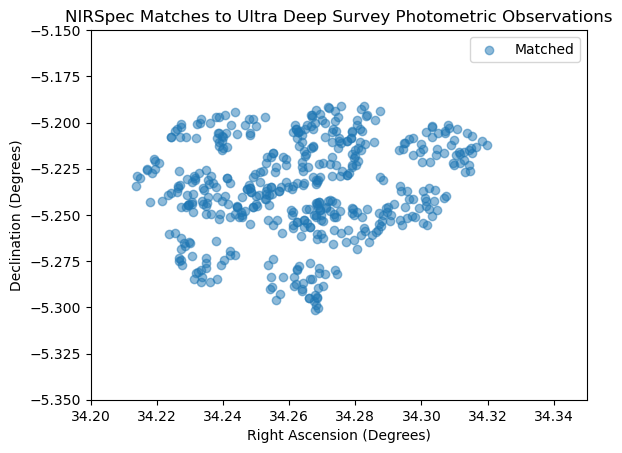

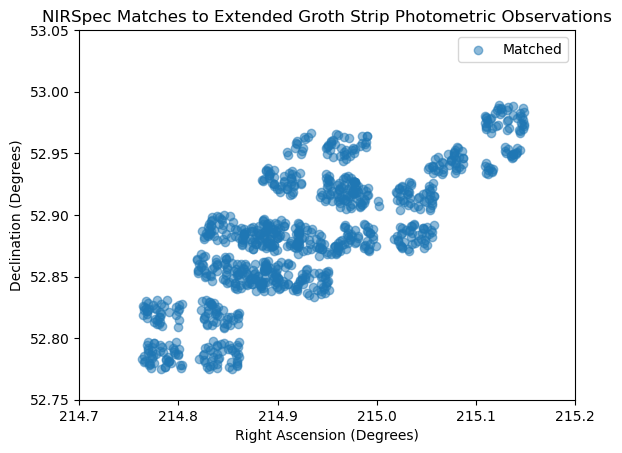

In [13]:
#Display the matched vs, unmatched objects in both the UDS and EGS fields (the 2 fields covered by RUBIES and UNICORN)

plt.figure()
plt.scatter(matched_skycoord2.ra.deg, matched_skycoord2.dec.deg, label = "Matched", alpha = .5)
#plt.scatter(no_match_ra, no_match_dec, color = 'red', label = "Unmatched", alpha = .5)
plt.title("NIRSpec Matches to Ultra Deep Survey Photometric Observations")
plt.xlabel("Right Ascension (Degrees)")
plt.ylabel("Declination (Degrees)")
plt.xlim(34.2,34.35)
plt.ylim(-5.35, -5.15)
plt.legend()
plt.show()


plt.figure()
plt.scatter(matched_skycoord2.ra.deg, matched_skycoord2.dec.deg, label = "Matched", alpha = .5)
#plt.scatter(no_match_ra, no_match_dec, color = 'red', label = "Unmatched", alpha = .5)
plt.title("NIRSpec Matches to Extended Groth Strip Photometric Observations")
plt.xlabel("Right Ascension (Degrees)")
plt.ylabel("Declination (Degrees)")
plt.legend()
plt.xlim(214.7, 215.2)
plt.ylim(52.75, 53.05)
plt.show()

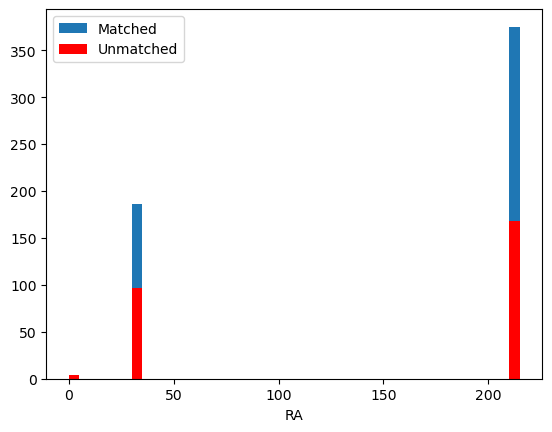

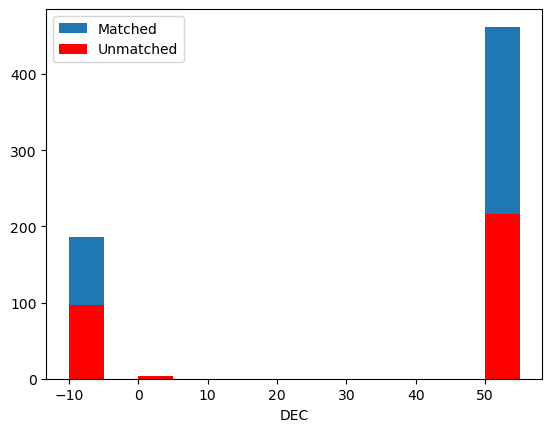

In [459]:
#Display the ratio of matched and unmatched objects with histograms (the two columns indicate the two fields)

plt.figure()
plt.hist(matched_skycoord2.ra.deg, label = "Matched", bins =np.arange(0,220,5))
plt.hist(no_match_ra, color = 'red', label = "Unmatched", bins = np.arange(0,220,5))
plt.xlabel("RA")
plt.legend()
plt.show()

plt.figure()
plt.hist(matched_skycoord2.dec.deg, label = "Matched", bins = np.arange(-10,60,5))
plt.hist(no_match_dec, color = 'red', label = "Unmatched", bins = np.arange(-10, 60, 5))
plt.legend()
plt.xlabel("DEC")
plt.show()

In [410]:
#Guiding broad instructions if needed...

#First, CALCULATE magnitude so that we can later bin it...use flux through z-dep filters

#Then, bin up unicorn_areaz by redshifts

#Then, bin up those by magnitude

#Then, crossmatch using skycoords between the 1951 spectra and the 60798 total objects within my range.

#Once cross-matched, take the number of matches and divide by the total unicorn_areaz number in that redshift/magnitude bin

#Create completeness percentage plots for different redshifts as a function of magnitude

REMEBER: I don't need to bin up rubies_samplez, as I can just take the number of matches in each unicorn_areaz bin!

In [125]:
#CALCULATE magnitude so that we can later bin it...use flux through z-dep filters

#The flux filter for which we measure flux from changes based on redshift as we want h-alpha in the proper range

filter_list = ['FLUX_F090W', 'FLUX_F115W', 'FLUX_F150W', 'FLUX_F200W', 'FLUX_F277W', 'FLUX_F356W', 'FLUX_F444W']
fluxes=[]
for num, z in enumerate(unicorn_areaz['ZPEAK']):
    if z >0 and z <= .54:
        flux_filter = filter_list[0]
    if z > .55 and z <=.98:
        flux_filter = filter_list[1]
    if z > .99 and z<= 1.6:
        flux_filter = filter_list[2]
    if z > 1.61 and z <= 2.52:
        flux_filter = filter_list[3]
    elif z>2.52 and z<=3.72:
        flux_filter = filter_list[4]
    elif z>3.72 and z<=4.96:
        flux_filter = filter_list[5]
    else:
        flux_filter = filter_list[6]
    flux = (unicorn_areaz[num][flux_filter]) #collecting the proper flux variable
    fluxes.append(flux)


In [126]:
#Converting flux to magnitude, ignore nans(as replacing them with 0 doesnt work in magnitude space)
mag_vals=[]
for flux in fluxes:
    mag_vals.append(-2.5*np.log10(flux) + 31.4)
mag_vals

#add this magnitude column to the unicorn_areaz table
unicorn_areaz['Magnitude'] = mag_vals
unicorn_areaz['Fluxes'] = fluxes

C:\Users\15125\AppData\Local\Temp\ipykernel_17272\2121370297.py:4: RuntimeWarning: invalid value encountered in log10
  mag_vals.append(-2.5*np.log10(flux) + 31.4)


In [127]:
#Then, bin up unicorn_areaz by redshifts (6 total)

zs = np.arange(2.5,8.5)
unicorn_zbins=[]
#rubies_zbins=[]
for z in zs:
    binner = unicorn_areaz[np.abs(unicorn_areaz['ZPEAK']-z)<0.5]
    unicorn_zbins.append(binner)
#     binner = rubies_samplez[np.abs(rubies_samplez['z_test']-z)<0.5]
#     rubies_zbins.append(binner)
    


In [129]:
#Then, bin up by magnitude within each redshift bin (13 each, 72 total)

mags = np.arange(16,40,1)
unicorn_magbins_z2 =[] #CENTERED at 2.5, and so on...
unicorn_magbins_z3 =[]
unicorn_magbins_z4 =[]
unicorn_magbins_z5 =[]
unicorn_magbins_z6 =[]
unicorn_magbins_z7 =[]
unicorn_magbins = [unicorn_magbins_z2, unicorn_magbins_z3, unicorn_magbins_z4, unicorn_magbins_z5, unicorn_magbins_z6,unicorn_magbins_z7]
for zbin in range(len(unicorn_magbins)):
    for mag in mags:
        binner = unicorn_zbins[zbin][np.abs(unicorn_zbins[zbin]['Magnitude'] - mag)<.5]
        unicorn_magbins[zbin].append(binner)

#Now, each of the 6 redshift bins have 13 magbins with a certain amount of objects in them

In [130]:
#FInd the number of objects in each z+mag bin..these are the denominators
total_count=[]
for z in range(len(zs)):
    print()
    for mag in range(len(unicorn_magbins[z])):
        total_count.append(len(unicorn_magbins[z][mag]))

In [131]:
#Now, we divide the number of rubies_samplez cross-matched objects in each bin..
print(len(unicorn_magbins[0]))


#Count the number of matches in each redshift and magnitude bin
match_count=[]
for z in range(len(zs)):
    for mag in range(len(unicorn_magbins[z])):
        matches=[]
        for i in unicorn_magbins[z][mag]['RA']:
            if i in list(matched_skycoord1.ra.deg):
                matches.append(i)
        match_count.append(len(matches))


24

In [133]:
#Now, we can calculate the percentage of objects that we have NIRSpec spectra for in each redshift and magnitude bin

total_count = np.array(total_count)
match_count = np.array(match_count)

percentage = (match_count/total_count)*100

percentage

C:\Users\15125\AppData\Local\Temp\ipykernel_17272\2513087428.py:4: RuntimeWarning: invalid value encountered in true_divide
  percentage = (match_count/total_count)*100


array([        nan,         nan,         nan,  0.        ,  0.        ,
        0.        ,  7.60869565,  6.25      ,  2.23684211,  1.98961938,
        0.7231405 ,  0.81736189,  0.72345813,  0.32341527,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
               nan,         nan,         nan,         nan,  0.        ,
               nan,  0.        ,  0.        ,  0.        ,  0.        ,
       16.        ,  9.16030534, 12.30769231,  7.43944637,  4.77081384,
        2.16802168,  1.17594852,  0.26236125,  0.2       ,  0.        ,
        0.        ,  0.        ,  0.        ,         nan,  0.        ,
               nan,         nan,         nan,         nan,         nan,
               nan,  0.        ,  0.        ,  0.        , 14.28571429,
       21.05263158, 10.28037383, 10.68376068,  6.77290837,  3.09769658,
        1.27082745,  0.15500443,  0.12602394,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,      

In [134]:
#Chunk these into redshift bins for easier indexing

chunked = [percentage[i:i + 24] for i in range(0, len(percentage), 24)]

#Create color wheel to iterate through for redshift
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', 'black']


In [135]:
#Display redshift-separated observational completeness percentages
chunked

[array([       nan,        nan,        nan, 0.        , 0.        ,
        0.        , 7.60869565, 6.25      , 2.23684211, 1.98961938,
        0.7231405 , 0.81736189, 0.72345813, 0.32341527, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
               nan,        nan,        nan,        nan]),
 array([ 0.        ,         nan,  0.        ,  0.        ,  0.        ,
         0.        , 16.        ,  9.16030534, 12.30769231,  7.43944637,
         4.77081384,  2.16802168,  1.17594852,  0.26236125,  0.2       ,
         0.        ,  0.        ,  0.        ,  0.        ,         nan,
         0.        ,         nan,         nan,         nan]),
 array([        nan,         nan,         nan,  0.        ,  0.        ,
         0.        , 14.28571429, 21.05263158, 10.28037383, 10.68376068,
         6.77290837,  3.09769658,  1.27082745,  0.15500443,  0.12602394,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,    

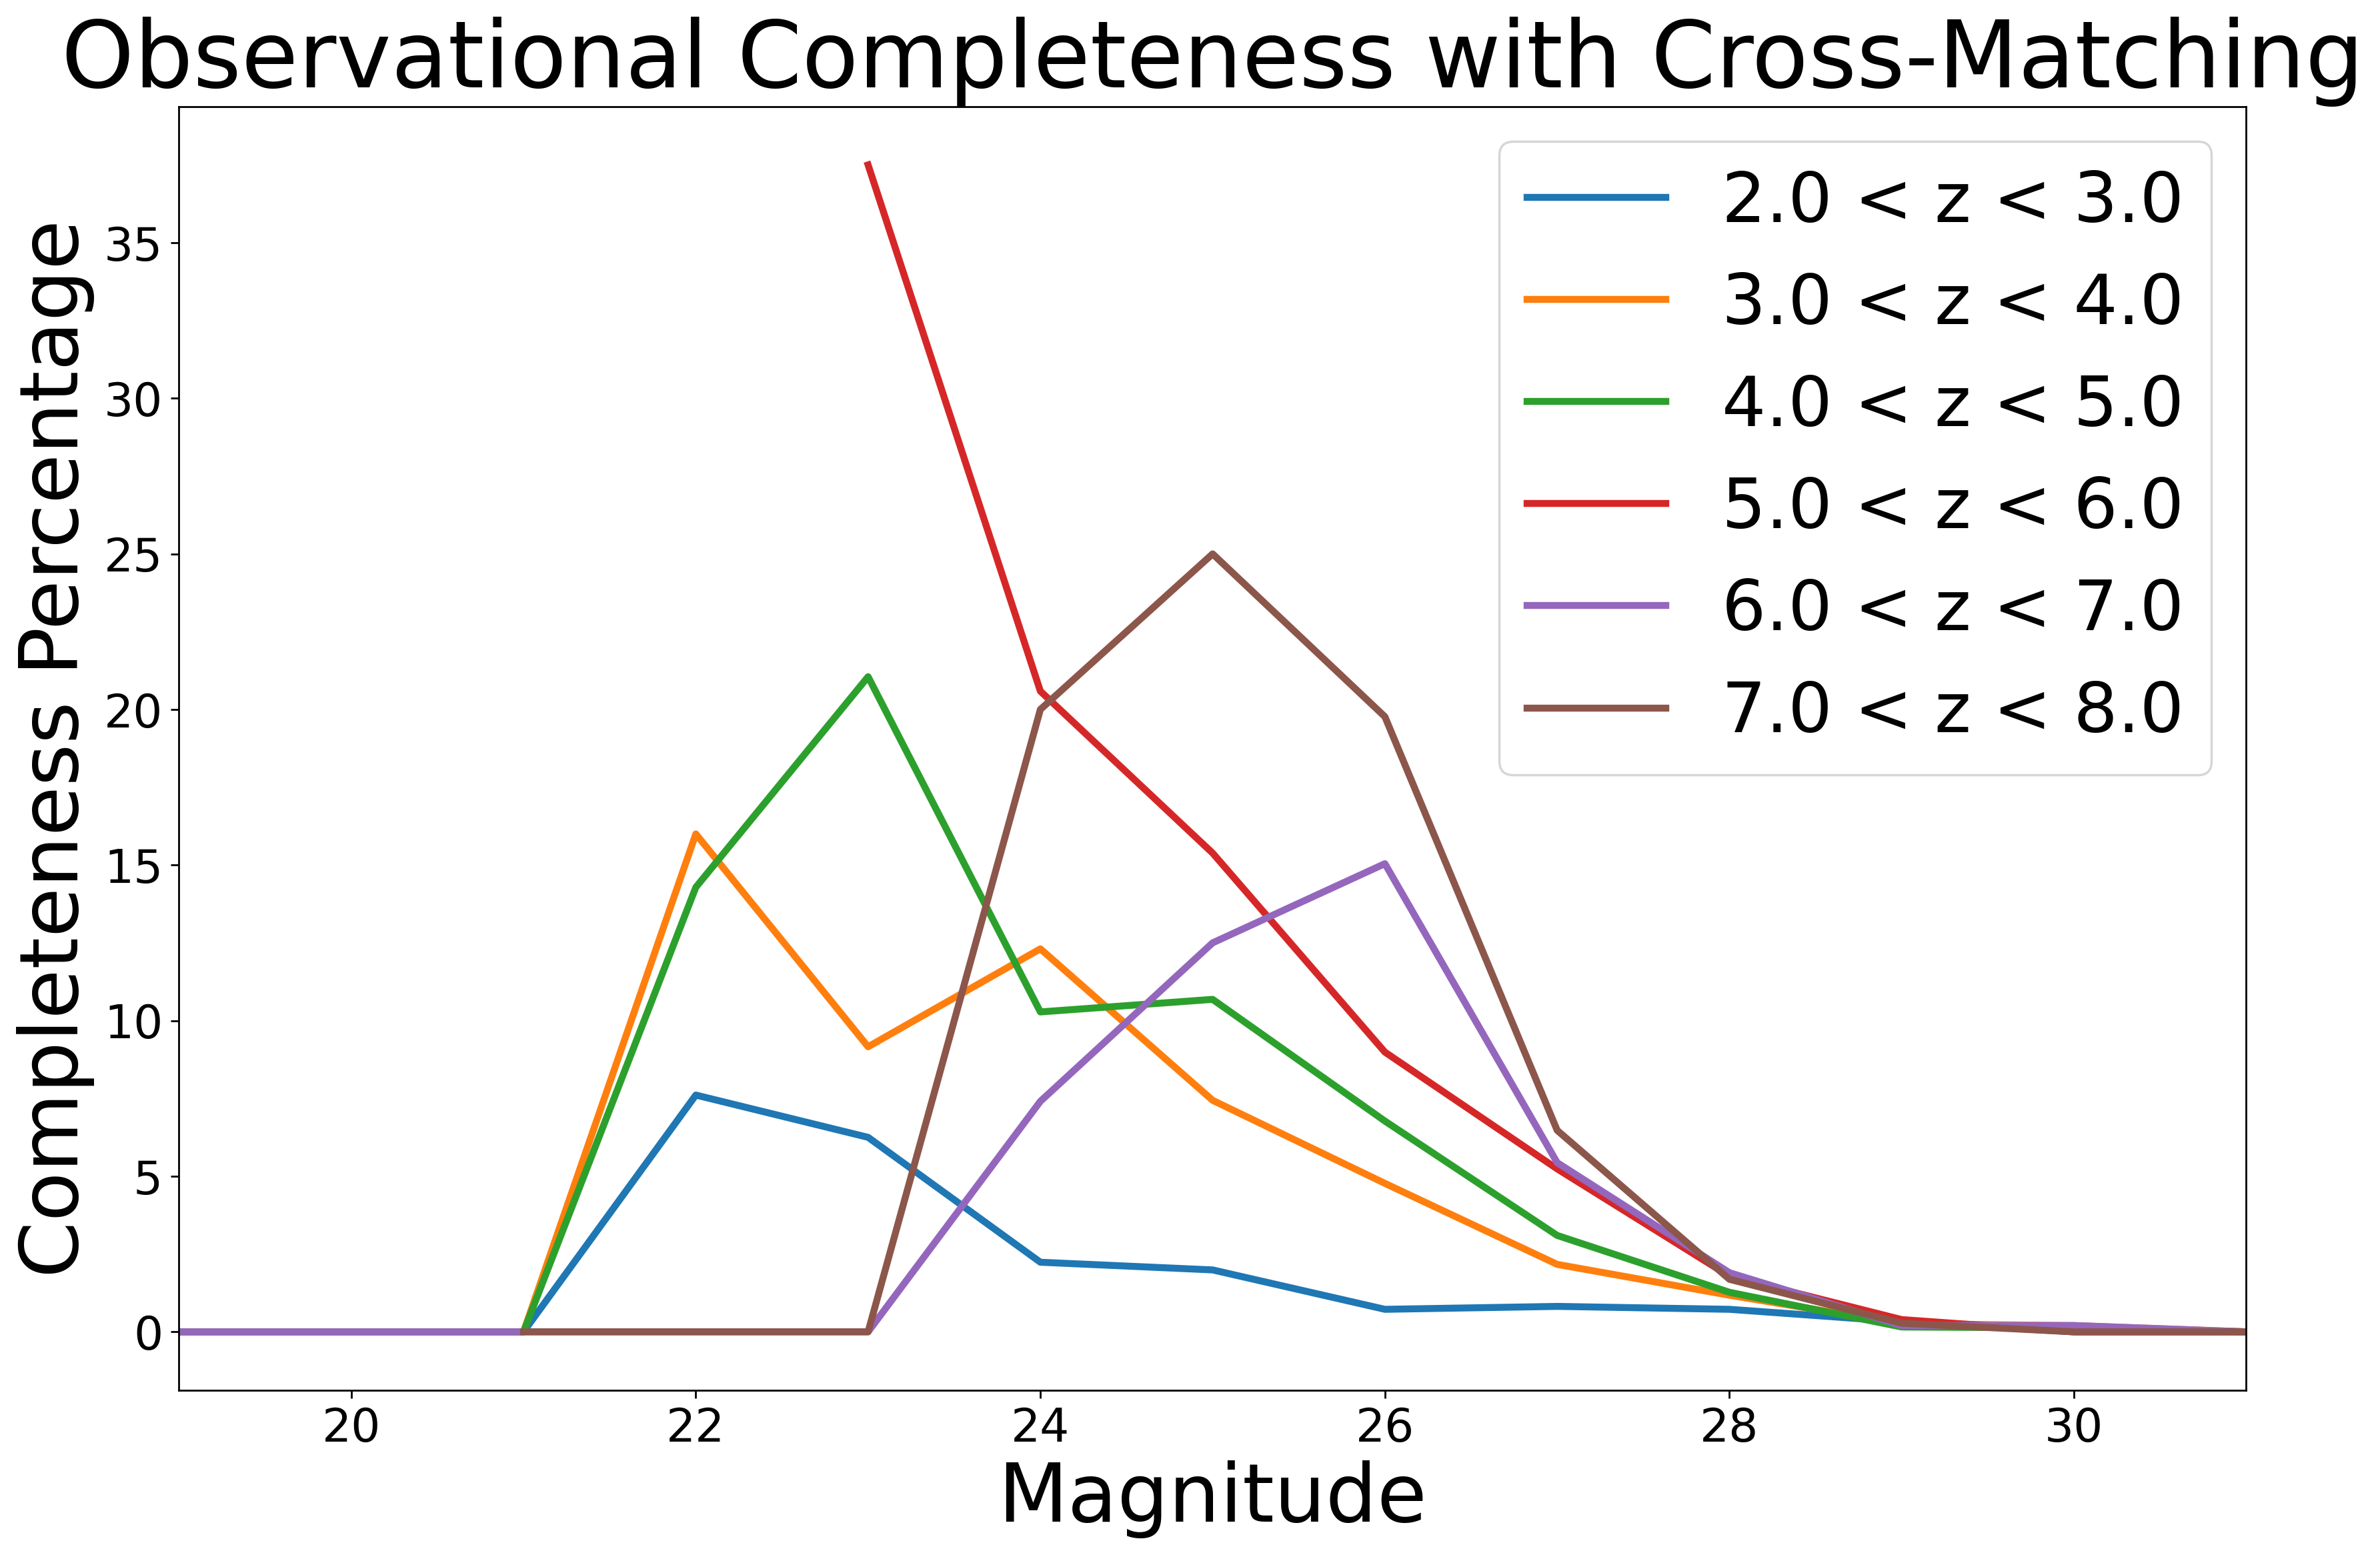

In [138]:
#Plot the observational completeness percentage as a function of magnitude for each redshift bin

ax = plt.figure(figsize = (16,10), dpi = 250)
for i in range(len(chunked)):
    plt.plot(mags, chunked[i], color = colors[i], label = str(zs[i]-.5) + " < z < " + str(zs[i]+.5), linewidth = 3)
    plt.xlabel("Magnitude", fontsize = 35)
    plt.ylabel("Completeness Percentage", fontsize = 35)
    plt.title("Observational Completeness with Cross-Matching", fontsize = 40)
    plt.tick_params(axis = "both", labelsize = 20)
    plt.legend(fontsize = 30)
    plt.xlim(19,31)
plt.show()

In [60]:
#go through 903 sources, get their completeness according to their mag+z, store as weight
chunked = np.array(chunked) #gives percents
print(1/chunked) #gives weights per bin
print(mags)

[[       nan        nan        nan        inf        inf        inf
  0.13142857 0.16       0.44705882 0.5026087  1.38285714 1.22344828
  1.38225    3.092             inf        inf        inf        inf
         inf        inf        nan        nan        nan        nan]
 [       inf        nan        inf        inf        inf        inf
  0.0625     0.10916667 0.08125    0.1344186  0.20960784 0.46125
  0.85037736 3.81153846 5.                inf        inf        inf
         inf        nan        inf        nan        nan        nan]
 [       nan        nan        nan        inf        inf        inf
  0.07       0.0475     0.09727273 0.0936     0.14764706 0.32282051
  0.78688889 6.45142857 7.935             inf        inf        inf
         inf        inf        inf        nan        nan        nan]
 [       nan        inf        inf        nan        inf        nan
         nan 0.02666667 0.04857143 0.065      0.11125    0.19096774
  0.55923077 2.54375           inf        inf   

C:\Users\15125\AppData\Local\Temp\ipykernel_17272\485916788.py:3: RuntimeWarning: divide by zero encountered in true_divide
  print(1/chunked) #gives weights per bin


In [61]:
#These are the weights we will multiply each object in the many tables above by

weights = (1/chunked)*100
weights

C:\Users\15125\AppData\Local\Temp\ipykernel_17272\318486945.py:3: RuntimeWarning: divide by zero encountered in true_divide
  weights = (1/chunked)*100


array([[         nan,          nan,          nan,          inf,
                 inf,          inf,  13.14285714,  16.        ,
         44.70588235,  50.26086957, 138.28571429, 122.34482759,
        138.225     , 309.2       ,          inf,          inf,
                 inf,          inf,          inf,          inf,
                 nan,          nan,          nan,          nan],
       [         inf,          nan,          inf,          inf,
                 inf,          inf,   6.25      ,  10.91666667,
          8.125     ,  13.44186047,  20.96078431,  46.125     ,
         85.03773585, 381.15384615, 500.        ,          inf,
                 inf,          inf,          inf,          nan,
                 inf,          nan,          nan,          nan],
       [         nan,          nan,          nan,          inf,
                 inf,          inf,   7.        ,   4.75      ,
          9.72727273,   9.36      ,  14.76470588,  32.28205128,
         78.68888889, 645.14285714, 79

In [62]:
#Now I have filtered rubies. I am going to calculate weights, and then add these weights into the original rubies_samplez
filt_rubies_zbins=[]
for z in zs:
    binner = filtered_rubies[np.abs(filtered_rubies['z_test']-z)<0.5]
    filt_rubies_zbins.append(binner)
    
    
filt_rubies_zbins[0]

filt_rubies_magbins = [[] for _ in range(6)]
for z in range(len(filt_rubies_zbins)):
    for mag in mags:
        binner = filt_rubies_zbins[z][np.abs(filt_rubies_zbins[z]['Magnitude'] - (mag+.5))<.5]
        filt_rubies_magbins[z].append(binner)



In [63]:
#This is now a list of lists of tables. there are 6 lists for each redshift range, and each of those has 24 mag lists
#each of those 24 mag lists is an Astropy Table with all the required columns. now I need to match these to chunked bins above
z_ind = 0
keeps=[]
for z in filt_rubies_magbins:
    mag_ind = 0
    for mag in z:
        display(mag)
        print(weights[z_ind][mag_ind])
        if len(mag) >0:
            mag['Weight'] = weights[z_ind][mag_ind]
            keeps.append(mag)
        mag_ind+=1
    z_ind+=1
        

MSA_ID,RUBIES RA,RUBIES DEC,filename,z_test,resids,Magnitude,UNICORN RA,UNICORN DEC
int64,float64,float64,bytes60,float64,float64,float64,float64,float64


nan


MSA_ID,RUBIES RA,RUBIES DEC,filename,z_test,resids,Magnitude,UNICORN RA,UNICORN DEC
int64,float64,float64,bytes60,float64,float64,float64,float64,float64


nan


MSA_ID,RUBIES RA,RUBIES DEC,filename,z_test,resids,Magnitude,UNICORN RA,UNICORN DEC
int64,float64,float64,bytes60,float64,float64,float64,float64,float64


...

inf


MSA_ID,RUBIES RA,RUBIES DEC,filename,z_test,resids,Magnitude,UNICORN RA,UNICORN DEC
int64,float64,float64,bytes60,float64,float64,float64,float64,float64


nan


MSA_ID,RUBIES RA,RUBIES DEC,filename,z_test,resids,Magnitude,UNICORN RA,UNICORN DEC
int64,float64,float64,bytes60,float64,float64,float64,float64,float64


nan


In [64]:
#Now, just need to recombine all the minitables with weights into a big one again
#Now, each source that was matched between RUBIES and UNICORN as a weight depending on the observational completeness percentage
#of an object with its specific redshift and magnitude(which is calculated through a redshift-dependent filter)
#This for 900+ objects, which include most of the 504 objects in my actual sample. I will multiply each object by its weight
#when I plot the corrected LFs

from astropy.table import vstack

filtered_rubies_weights = vstack(keeps)
filtered_rubies_weights

MSA_ID,RUBIES RA,RUBIES DEC,filename,z_test,resids,Magnitude,UNICORN RA,UNICORN DEC,Weight
int64,float64,float64,bytes60,float64,float64,float64,float64,float64,float64
43891,214.88619300916,52.85712735201,jw04233006003_CEERS-FULL-V2_CLEAR_PRISM_s43891_x1d.fits,2.7571774138331833,2626.842703607639,19.02143403328501,214.886195574908,52.85711611780063,inf
45468,34.3040698,-5.236710899999991,jw04233001003_PRIMER-UDS-FULL-V4_CLEAR_PRISM_s45468_x1d.fits,2.16084440614815,3141.3548588614703,21.899921609880828,34.30404983323542,-5.236688922705472,inf
32830,214.82435342173,52.78618253597,jw04233005003_CEERS-FULL-V2_CLEAR_PRISM_s32830_x1d.fits,2.2950576813787915,1469.81706426995,21.01890642518551,214.8243528302927,52.78617865339638,inf
75928,214.83085199264,52.89234846839,jw04233006002_CEERS-FULL-V2_CLEAR_PRISM_s75928_x1d.fits,2.403163952260017,3098.14076157186,21.01504251609724,214.83085057741056,52.89234829162348,inf
26634,214.83230896999,52.77775990786,jw04233005003_CEERS-FULL-V2_CLEAR_PRISM_s26634_x1d.fits,2.8886237454349866,2525.6270968690674,21.707482484137575,214.83230957412826,52.777756675513096,inf
41454,214.8747226328,52.84373832645,jw04233006003_CEERS-FULL-V2_CLEAR_PRISM_s41454_x1d.fits,2.9859897486665887,2536.8591012307033,21.354327966346506,214.87472104195757,52.84373767089115,inf
38208,214.89878242055,52.85248740464,jw04233006002_CEERS-FULL-V2_CLEAR_PRISM_s38208_x1d.fits,2.324649068004055,2624.2136530038083,21.652816364767222,214.89879173530653,52.852483566471335,inf
33947,214.94702234849,52.87616185457,jw04233006003_CEERS-FULL-V2_CLEAR_PRISM_s33947_x1d.fits,2.0020815510386263,492.3692464641911,21.754482868128598,214.9470221523102,52.876159103256235,inf
26825,214.95953025679,52.87000643404,jw04233006003_CEERS-FULL-V2_CLEAR_PRISM_s26825_x1d.fits,2.4565326100443845,1041.6536988836128,21.15870970964992,214.95953134408555,52.87000891734507,inf


In [65]:
#Removing the nan and inf values (as this would mean there are no UNICORN or RUBIES/both object respectively, in that bin)

weight_mask = ~np.isnan(filtered_rubies_weights["Weight"]) & ~np.isinf(filtered_rubies_weights["Weight"])

rubies_weights = filtered_rubies_weights[weight_mask]
rubies_weights

MSA_ID,RUBIES RA,RUBIES DEC,filename,z_test,resids,Magnitude,UNICORN RA,UNICORN DEC,Weight
int64,float64,float64,bytes60,float64,float64,float64,float64,float64,float64
27711,34.2285462,-5.267028100000005,jw04233001001_PRIMER-UDS-FULL-V4_CLEAR_PRISM_s27711_x1d.fits,2.3899526529978026,317.14283515489393,22.708161187575897,34.228536928589236,-5.266989388499578,13.142857142857142
62812,34.2622095,-5.20347129999999,jw04233001003_PRIMER-UDS-FULL-V4_CLEAR_PRISM_s62812_x1d.fits,2.7503652375779124,867.6645071933707,22.874968027198253,34.26219875923514,-5.203430374339907,13.142857142857142
64018,34.2652411,-5.201242600000001,jw04233001003_PRIMER-UDS-FULL-V4_CLEAR_PRISM_s64018_x1d.fits,2.0879159063665806,973.6015286357901,22.217512762392005,34.2652331358407,-5.201204025349162,13.142857142857142
50352,34.277488,-5.228168799999992,jw04233001002_PRIMER-UDS-FULL-V4_CLEAR_PRISM_s50352_x1d.fits,2.0791604708699016,937.1121245176543,22.2935289899216,34.27746761626151,-5.228140001460478,13.142857142857142
33685,34.2825864,-5.257016000000021,jw04233001001_PRIMER-UDS-FULL-V4_CLEAR_PRISM_s33685_x1d.fits,2.6073012742826993,754.8562482828324,22.8020979457509,34.282564994155585,-5.2569932020185615,13.142857142857142
45479,34.2936856,-5.237008800000012,jw04233001003_PRIMER-UDS-FULL-V4_CLEAR_PRISM_s45479_x1d.fits,2.8850454376573884,2778.862390288671,22.67346732952857,34.2936661433787,-5.236988118159124,13.142857142857142
61168,214.86605335403,52.88425717846,jw04233006002_CEERS-FULL-V2_CLEAR_PRISM_s61168_x1d.fits,2.566394787777475,2936.725907192484,22.13614208960694,214.8660441027287,52.884253205472106,13.142857142857142
54410,214.87125517681,52.87386636136,jw04233006003_CEERS-FULL-V2_CLEAR_PRISM_s54410_x1d.fits,2.332781915716307,2502.618138877918,22.96601684394577,214.8712434974245,52.87386158470329,13.142857142857142
44021,214.87628582043,52.85234681171,jw04233006003_CEERS-FULL-V2_CLEAR_PRISM_s44021_x1d.fits,2.89322757729696,323.456220001458,22.59718376271642,214.87628937224122,52.852345507450835,13.142857142857142


In [66]:
rubies_weights.show_in_browser()